# Решение задания по датасету **Heart Disease Health Indicators Dataset**.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
from matplotlib import pyplot as plt

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from sklearn.metrics import classification_report, roc_auc_score


In [ ]:
dataset = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv')
target = 'HeartDiseaseorAttack'
feature_names = [col for col in dataset.columns if col != target]

print(f'Размер датасета: {dataset.shape}')
print(f'Целевая переменная: {target}')
print(f'Количество факторов: {len(feature_names)}')
print(f"Число наблюдений класса 0: {int(dataset[target].value_counts().sort_index().loc[0.0])}")
print(f"Число наблюдений класса 1: {int(dataset[target].value_counts().sort_index().loc[1.0])}")
print(f"Доля положительного класса: {dataset[target].mean():.4%}")


Размер датасета: (253680, 22)
Целевая переменная: HeartDiseaseorAttack
Количество факторов: 21
Число наблюдений класса 0: 229787
Число наблюдений класса 1: 23893
Доля положительного класса: 9.4186%


In [ ]:
def train_binary(dataset, target, feature_names, plot_feature, model_type='logit', pkg='statsmodels', class_weight=None):

    dataset = dataset.copy()

    if pkg == 'statsmodels':
        if model_type == 'logit':

            # Реализация через statsmodels
            X = sm.add_constant(dataset[feature_names])
            model = Logit(dataset[target], X).fit(disp=0, maxiter=100)

        else:
            print('Please, choose Logit model!')

    else:
        raise ValueError('В этом ноутбуке используется только statsmodels-ветка из utils.py.')

    # Подготовим репорт с результатами модели
    metrics = show_binary_res(model, dataset[target], X, plot_feature, pkg)

    return(dataset, model, metrics)


def show_binary_res(model, y, X, plot_feature, pkg='statsmodels'):

    # Получаем предсказанные скоры модели
    if pkg == 'statsmodels':
        pred_proba = model.predict(X)
        pred_val = (pred_proba > 0.5).astype('int')
    else:
        raise ValueError('В этом ноутбуке используется только statsmodels-ветка из utils.py.')

    roc_auc = roc_auc_score(y.values, pred_proba)
    report_text = classification_report(y_pred=pred_val, y_true=y.values, zero_division=np.nan)

    match_df = pd.DataFrame({
        plot_feature: X[plot_feature],
        'Predicted': pred_val,
        'Predicted score': pred_proba,
        'Actual': y.astype(int)
    })

    conf_matrix = (
        match_df.groupby(['Actual', 'Predicted'])[['Actual']]
        .count()
        .rename(columns={'Actual': 'Value'})
        .reset_index()
        .pivot(index='Actual', columns='Predicted', values='Value')
        .fillna(0)
        .reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        .astype(int)
    )

    print('\n ================================================== TRAIN RESULTS ================================================== \n')
    print(f'ROC AUC score: {roc_auc:.4f}\n')
    print(report_text)
    print('\nConfusion matrix:')
    print(conf_matrix.to_string())

    return {
        'pred_proba': pred_proba,
        'pred_val': pred_val,
        'match_df': match_df,
        'conf_matrix': conf_matrix,
        'roc_auc': roc_auc,
        'report_text': report_text,
    }


================================================== TRAIN RESULTS ==================================================

ROC AUC score: 0.8473

Classification report:
              precision  recall  f1-score   support
class                                              
0                0.9160  0.9888    0.9510  229787.0
1                0.5423  0.1276    0.2066   23893.0
accuracy         0.9077  0.9077    0.9077  253680.0
macro avg        0.7292  0.5582    0.5788  253680.0
weighted avg     0.8808  0.9077    0.8809  253680.0

Confusion matrix:
Predicted       0     1
Actual                 
0          227214  2573
1           20844  3049

Из 100 случайных пациентов модель в среднем:
- корректно поставит диагноз 'склонность' примерно 1.20 чел.;
- ошибочно поставит диагноз 'склонность' примерно 1.01 чел.;
- упустит потенциально больных примерно 8.22 чел.;
- корректно отнесет к группе без диагноза примерно 89.57 чел.;
- всего верно классифицирует примерно 90.77 чел.;
- всего ошибется примерно

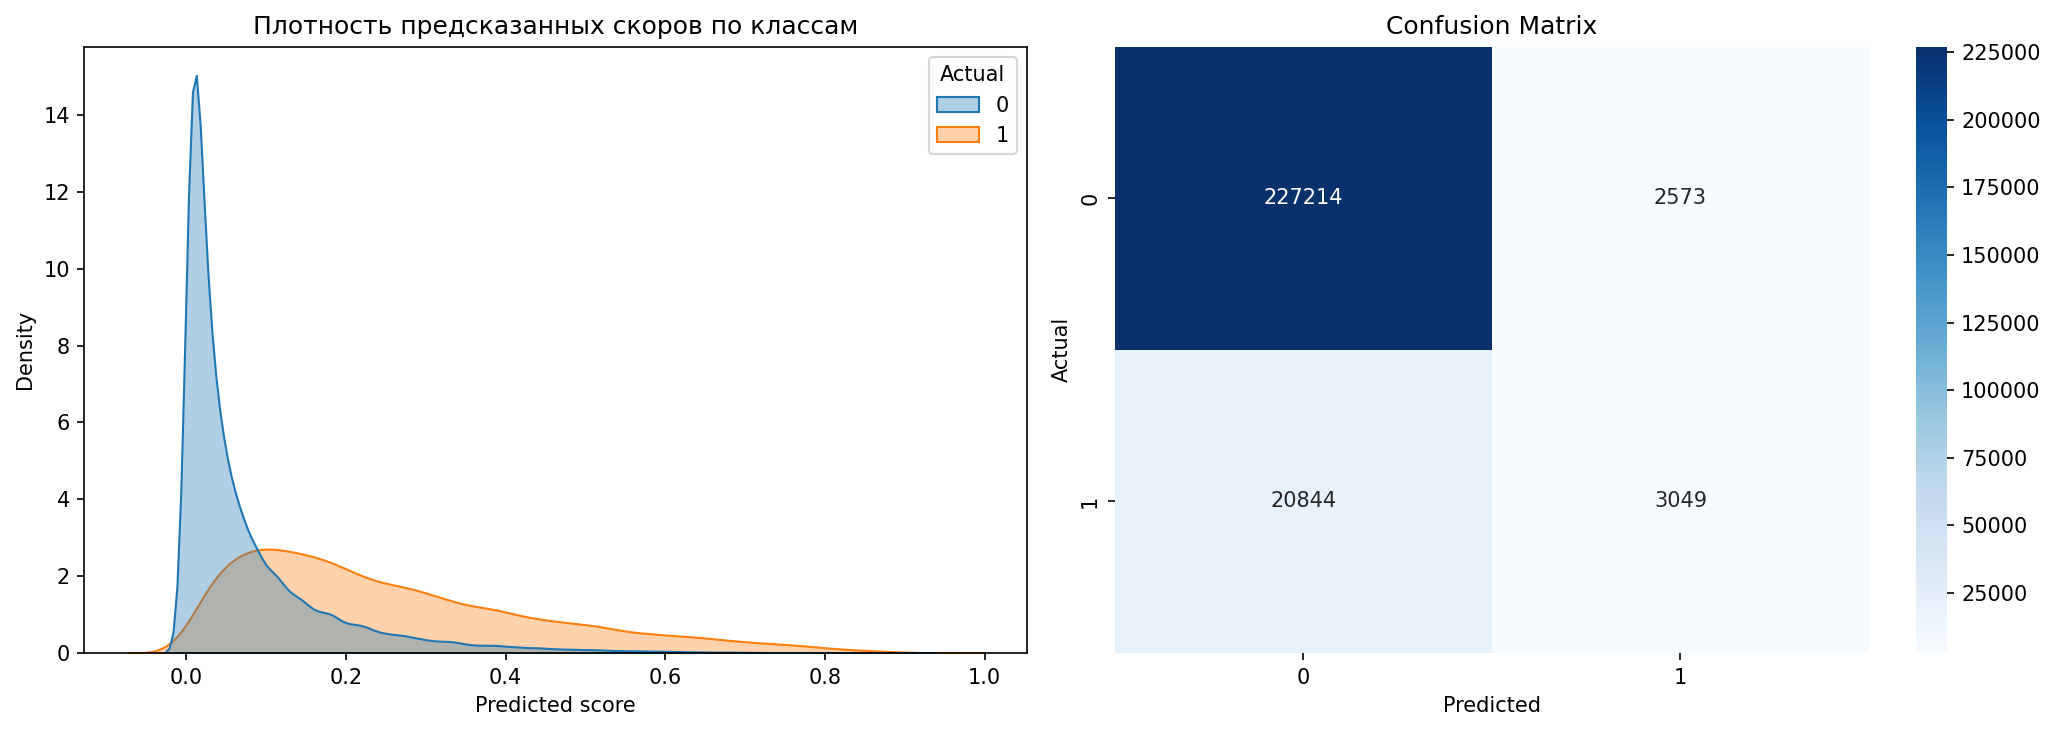

In [ ]:
dataset, model, metrics = train_binary(
    dataset,
    target='HeartDiseaseorAttack',
    feature_names=feature_names,
    plot_feature='Age',
    model_type='logit',
    pkg='statsmodels'
)

tp = int(metrics['conf_matrix'].loc[1, 1])
tn = int(metrics['conf_matrix'].loc[0, 0])
fp = int(metrics['conf_matrix'].loc[0, 1])
fn = int(metrics['conf_matrix'].loc[1, 0])
n_obs = len(dataset)

print()
print('Из 100 случайных пациентов модель в среднем:')
print(f"- корректно поставит диагноз 'склонность' примерно {tp / n_obs * 100:.2f} чел.;")
print(f"- ошибочно поставит диагноз 'склонность' примерно {fp / n_obs * 100:.2f} чел.;")
print(f"- упустит потенциально больных примерно {fn / n_obs * 100:.2f} чел.;")
print(f"- корректно отнесет к группе без диагноза примерно {tn / n_obs * 100:.2f} чел.;")
print(f"- всего верно классифицирует примерно {(tp + tn) / n_obs * 100:.2f} чел.;")
print(f"- всего ошибется примерно {(fp + fn) / n_obs * 100:.2f} чел.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sb.kdeplot(
    data=metrics['match_df'],
    x='Predicted score',
    hue='Actual',
    fill=True,
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title('Плотность предсказанных скоров по классам')
axes[0].set_xlabel('Predicted score')
axes[0].set_ylabel('Density')

sb.heatmap(metrics['conf_matrix'], annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Комментарии к результатам

### 1. Что говорят Precision и Recall

Для класса `1` (`HeartDiseaseorAttack = 1`) получили:
- `Precision ≈ 0.5423`
- `Recall ≈ 0.1276`

Это означает следующее:
- если модель уже поставила диагноз "склонность к сердечным болезням", то примерно в `54%` случаев это действительно пациент из положительного класса;
- но модель находит только около `12.8%` всех реально больных, то есть пропускает очень большую долю пациентов из группы риска.

Для медицинской задачи это плохой результат именно по `Recall`: модель слишком осторожна и почти всегда выбирает класс `0`.

### 2. Как трактовать F1-macro и ROC-AUC

- `F1-macro ≈ 0.5788` усредняет качество по обоим классам без учета дисбаланса. Эта метрика показывает, что в среднем качество умеренное и сильно проседает из-за слабого качества на классе `1`.
- `ROC-AUC ≈ 0.8473` означает, что модель в целом неплохо ранжирует пациентов по риску: случайный больной обычно получает более высокий скор, чем случайный здоровый.

Это важное сочетание:
- `ROC-AUC` хороший;
- но качество при фиксированном пороге `0.5` плохое для выявления больных.

Значит, проблема не только в признаках, но и в выбранном пороге классификации: модель умеет ранжировать риск, но текущий порог слишком высокий для задачи скрининга.

### 3. Интерпретация на 100 пациентов

Если брать 100 случайных пациентов и ставить диагноз только по текущей модели с порогом `0.5`, то в среднем:
- примерно `1.20` человеку диагноз "склонность" будет поставлен правильно;
- примерно `1.01` человеку такой диагноз будет поставлен ошибочно;
- примерно `8.22` потенциально больных модель пропустит;
- примерно `89.57` человек будут правильно отнесены к группе без диагноза.

### 4. Насколько модель годится для практики

В текущем виде модель **не подходит** как самостоятельный инструмент для практического выявления склонных к сердечным заболеваниям пациентов:
- она пропускает слишком много реально больных;
- высокая `accuracy` здесь обманчива, потому что датасет несбалансирован и класс `0` доминирует;
- для медицинского скрининга важнее существенно поднять `Recall` по классу `1`.

Итог: как модель ранжирования риска это уже неплохая база, но как готовый диагностический инструмент при текущем пороге она слишком слабая из-за большого числа пропущенных больных.
